# Stroke Prediction

## Import necessary libraries

In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_theme(style="whitegrid")

In [72]:
!pip install imblearn


   ---------------------------------------- 0/3 [sklearn-compat]
   ---------------------------------------- 0/3 [sklearn-compat]
   ---------------------------------------- 0/3 [sklearn-compat]
   ---------------------------------------- 0/3 [sklearn-compat]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
  

### Data Loading & Initial Inspection

In [3]:
path = r"C:\Users\ADMIN\Desktop\Logic Mojo_AIML Jan26\Resources\March\Week 3\healthcare-dataset-stroke-data.csv"

In [4]:
# Load the dataset
df = pd.read_csv(path)

# Look at the first 5 rows
df.head()

# Check data types and look for missing (null) values
print("\n--- Data Info ---")
df.info()

print("\n--- Summary Statistics ---")
display(df.describe(include='all'))


--- Data Info ---
<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   str    
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   str    
 6   work_type          5110 non-null   str    
 7   Residence_type     5110 non-null   str    
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   str    
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 479.2 KB

--- Summary Statistics ---


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
count,5110.000000,5110,5110.000000,5110.000000,5110.000000,5110,5110,5110,5110.000000,4909.000000,5110,5110.000000
unique,NaN,3,NaN,NaN,NaN,2,5,2,NaN,NaN,4,NaN
top,NaN,Female,NaN,NaN,NaN,Yes,Private,Urban,NaN,NaN,never smoked,NaN
freq,NaN,2994,NaN,NaN,NaN,3353,2925,2596,NaN,NaN,1892,NaN
mean,36517.829354,NaN,43.226614,0.097456,0.054012,NaN,NaN,NaN,106.147677,28.893237,NaN,0.048728
std,21161.721625,NaN,22.612647,0.296607,0.226063,NaN,NaN,NaN,45.283560,7.854067,NaN,0.215320
min,67.000000,NaN,0.080000,0.000000,0.000000,NaN,NaN,NaN,55.120000,10.300000,NaN,0.000000
25%,17741.250000,NaN,25.000000,0.000000,0.000000,NaN,NaN,NaN,77.245000,23.500000,NaN,0.000000
50%,36932.000000,NaN,45.000000,0.000000,0.000000,NaN,NaN,NaN,91.885000,28.100000,NaN,0.000000
75%,54682.000000,NaN,61.000000,0.000000,0.000000,NaN,NaN,NaN,114.090000,33.100000,NaN,0.000000


In [5]:
hypertension = df['hypertension'].value_counts()
heart_diseases = df['heart_disease'].value_counts()
print(hypertension)
print(heart_diseases)

hypertension
0    4612
1     498
Name: count, dtype: int64
heart_disease
0    4834
1     276
Name: count, dtype: int64


### Exploratory Data Analysis (EDA)

In [6]:
# 1. Start by defining our target and ID columns so we don't mix them up
target_col = 'stroke'
id_col = 'id'

# 2. Get all purely text columns
categorical_cols = df.select_dtypes(include=['str']).columns.tolist()
print("\n--- Categorical columns ---")
display(categorical_cols)

# 3. Get all numeric columns
numerical_columns = df.select_dtypes(exclude=['str']).columns.tolist()
print("\n--- Numerical columns ---")
display(numerical_columns)

# 4. Remove Target and ID from the numeric list
numerical_columns.remove(target_col)
numerical_columns.remove(id_col)
print("-- After removing target and Id columns--")
display(numerical_columns)

numerical_cols = []
for col in numerical_columns:
    # If it has less than 10 unique values, we treat it as a categorical feature
    if df[col].nunique() < 10:
        categorical_cols.append(col)
    else:
        numerical_cols.append(col)

print("Categorical Columns:\n", categorical_cols)
print("\nNumerical Columns:\n", numerical_cols)


--- Categorical columns ---


['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']


--- Numerical columns ---


['id',
 'age',
 'hypertension',
 'heart_disease',
 'avg_glucose_level',
 'bmi',
 'stroke']

-- After removing target and Id columns--


['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi']

Categorical Columns:
 ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status', 'hypertension', 'heart_disease']

Numerical Columns:
 ['age', 'avg_glucose_level', 'bmi']


### Univariate Analysis

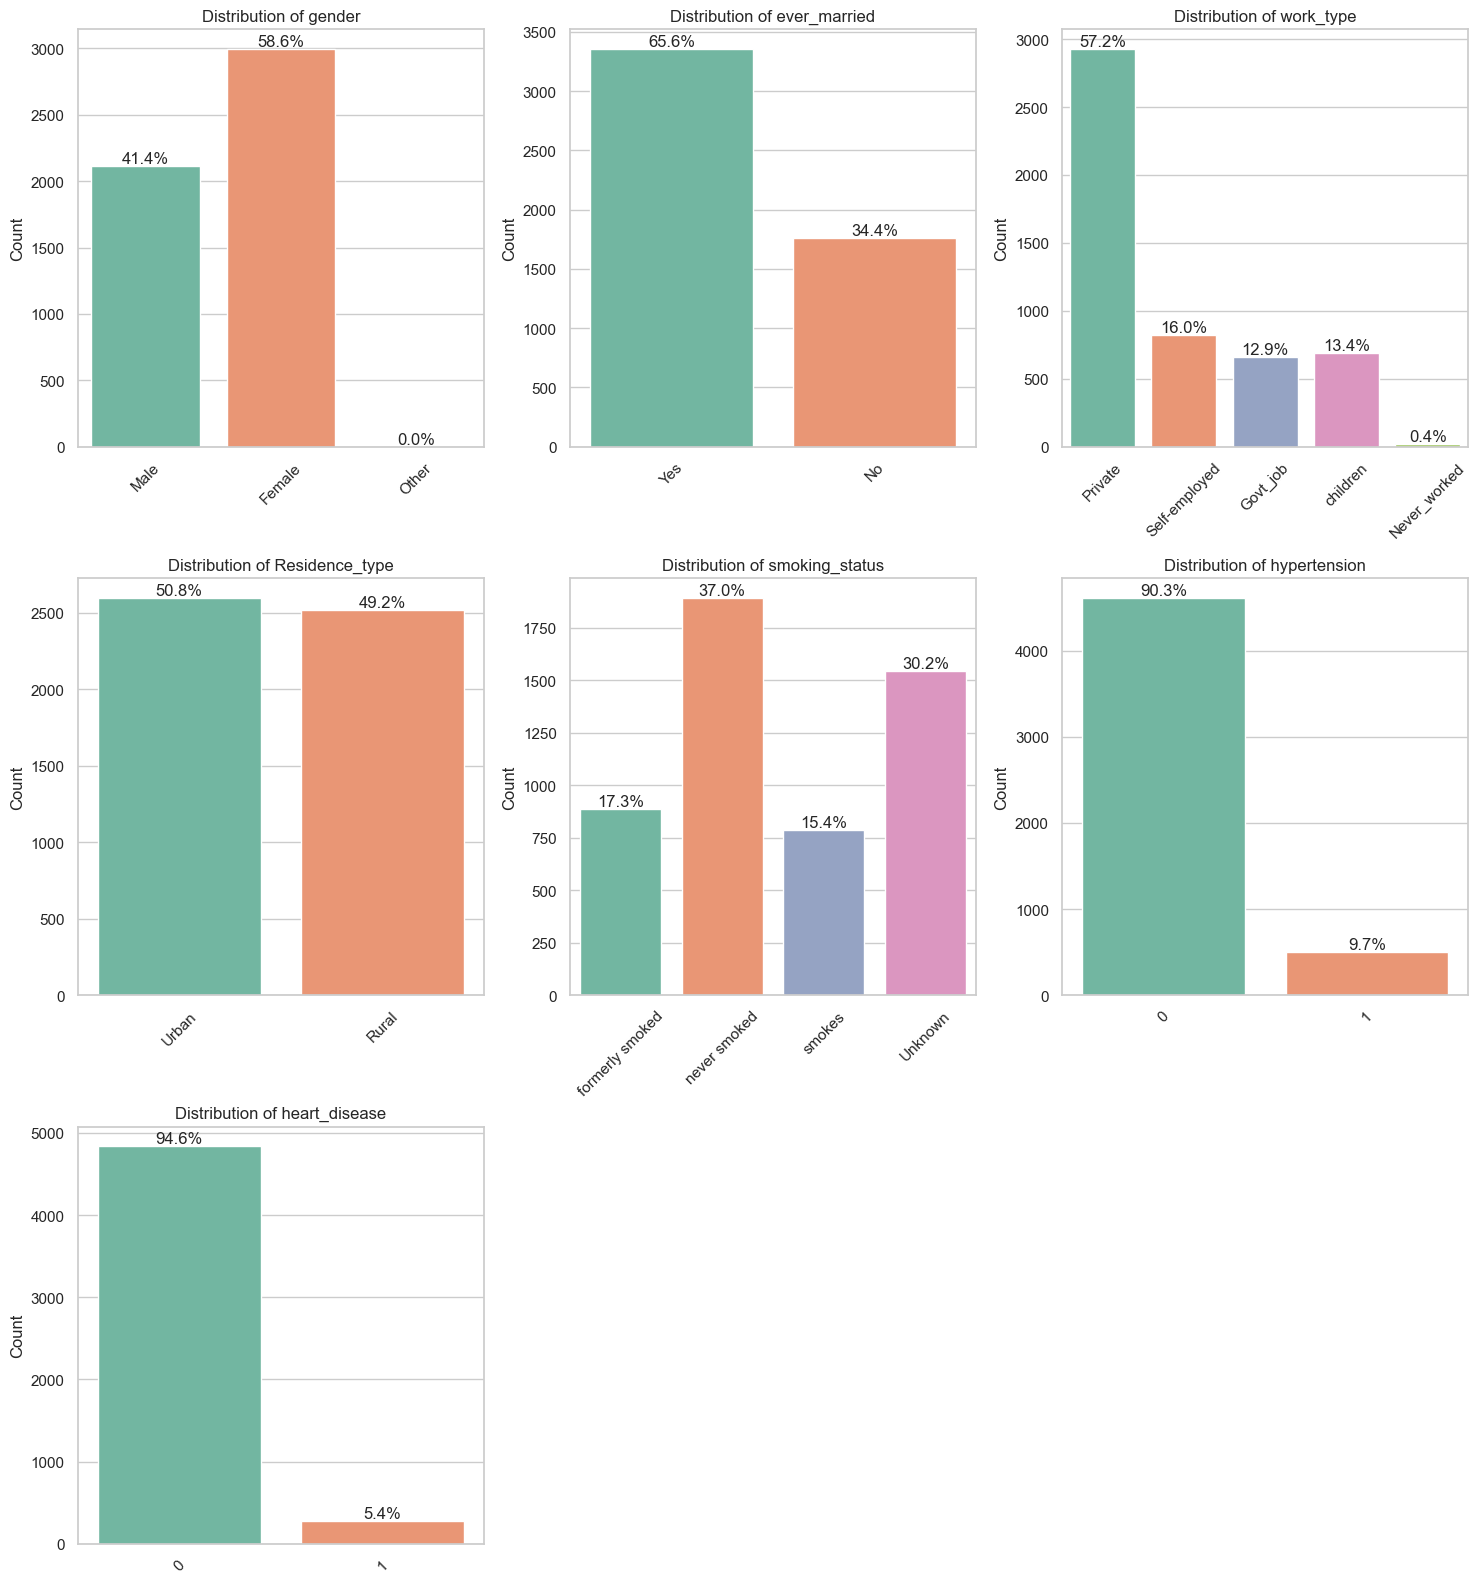

In [7]:
# Categorical Column
plt.figure(figsize=(15,16))

# Loop through each categorical column we identified earlier
for i, col in enumerate(categorical_cols):
    ax = plt.subplot(3, 3, i + 1)
    sns.countplot(data=df, x=col, palette='Set2')
    plt.title(f'Distribution of {col}', fontsize=12)
    plt.xlabel('')
    plt.ylabel('Count')
    
    # Rotate x-axis labels to prevent overlap if names are long
    plt.xticks(rotation=45)
    
    # Add percentage label on top of each bar to represent the proportion
    total = len(df) # Total number of rows in the dataset
    for p in ax.patches:
        # Calculate percentage: (height of bar / total rows) * 100
        percentage = f'{100 * p.get_height() / total:.1f}%'
        
        # Calculate the x and y coordinates to place the text
        x = p.get_x() + p.get_width() / 2
        y = p.get_height()
        
        # Annotate the specific percentage on the chart
        ax.annotate(percentage, (x, y), ha='center', va='bottom')
plt.tight_layout()
plt.show()



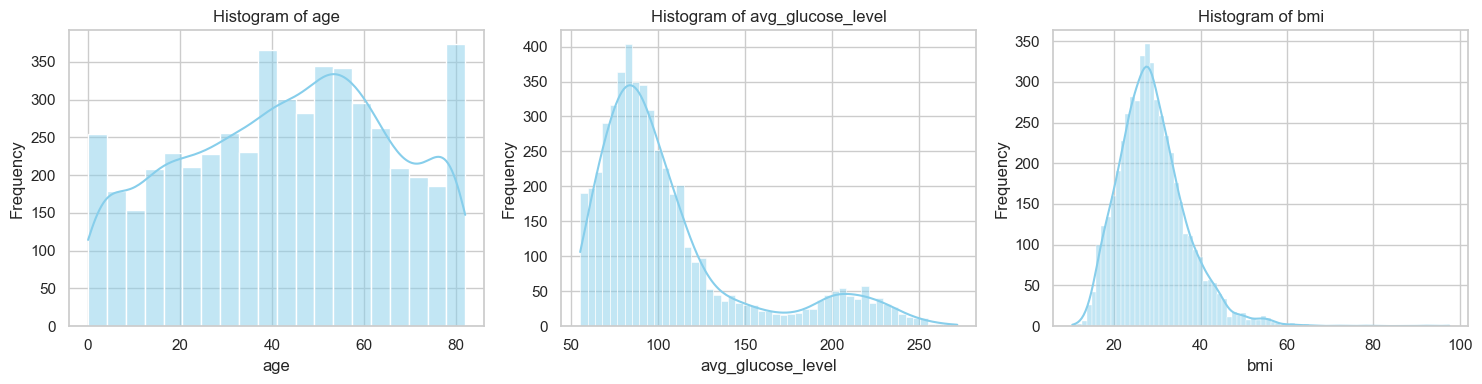

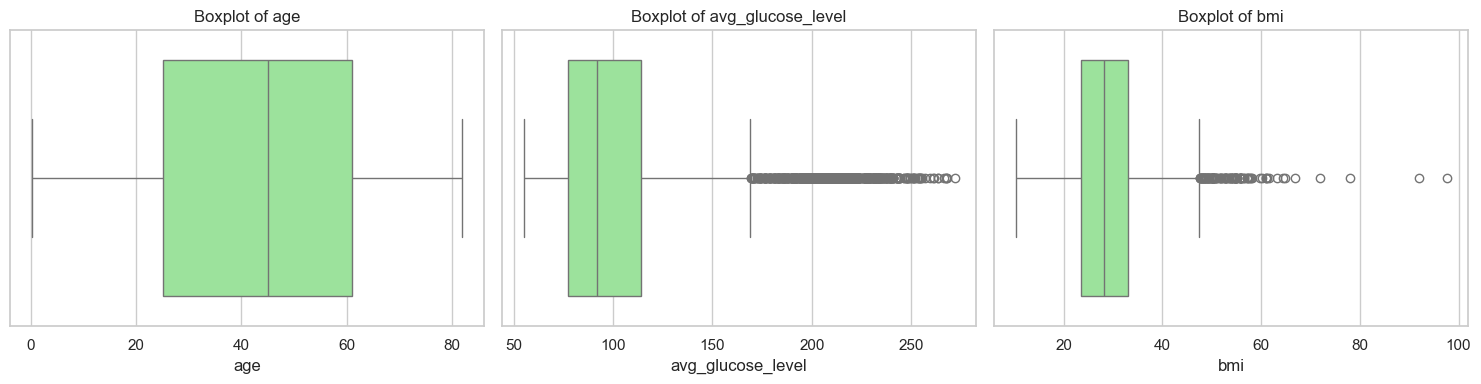

In [30]:
# Numerical Features (Histograms)
plt.figure(figsize=(15, 4))
for i, col in enumerate(numerical_cols):
    plt.subplot(1, 3, i + 1)
    sns.histplot(data=df, x=col, kde=True, color='skyblue')
    plt.title(f'Histogram of {col}', fontsize=12)
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# Numerical Features (Boxplots to check for Outliers)
plt.figure(figsize=(15, 4))
for i, col in enumerate(numerical_cols):
    plt.subplot(1, 3, i + 1)
    sns.boxplot(data=df, x=col, color='lightgreen')
    plt.title(f'Boxplot of {col}', fontsize=12)
    plt.xlabel(col)
plt.tight_layout()
plt.show()
     

### Target Columns

In [8]:
stroke_counts = df[target_col].value_counts()
print(stroke_counts)

stroke
0    4861
1     249
Name: count, dtype: int64


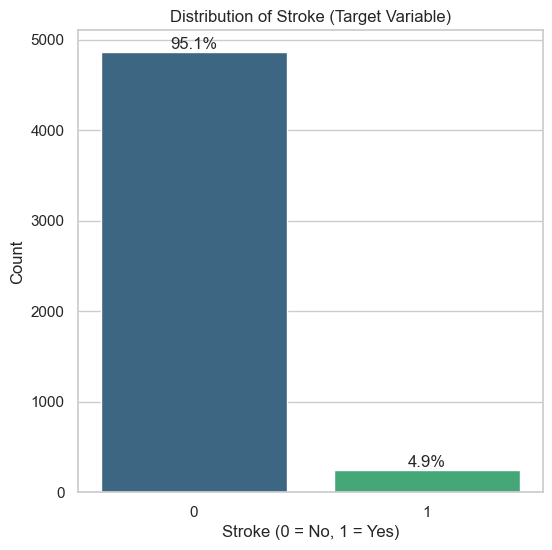


Proportions:
 stroke
0    0.951272
1    0.048728
Name: proportion, dtype: float64


In [9]:
# Visualize the distribution of the target
plt.figure(figsize=(6, 6))
ax = sns.countplot(data=df, x=target_col, palette='viridis')
plt.title('Distribution of Stroke (Target Variable)')
plt.xlabel('Stroke (0 = No, 1 = Yes)')
plt.ylabel('Count')

# Add percentage to each bar
total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom')

plt.show()

# Print exact numbers proportion
print("\nProportions:\n", df[target_col].value_counts(normalize=True))

### Bivariate Anlaysis

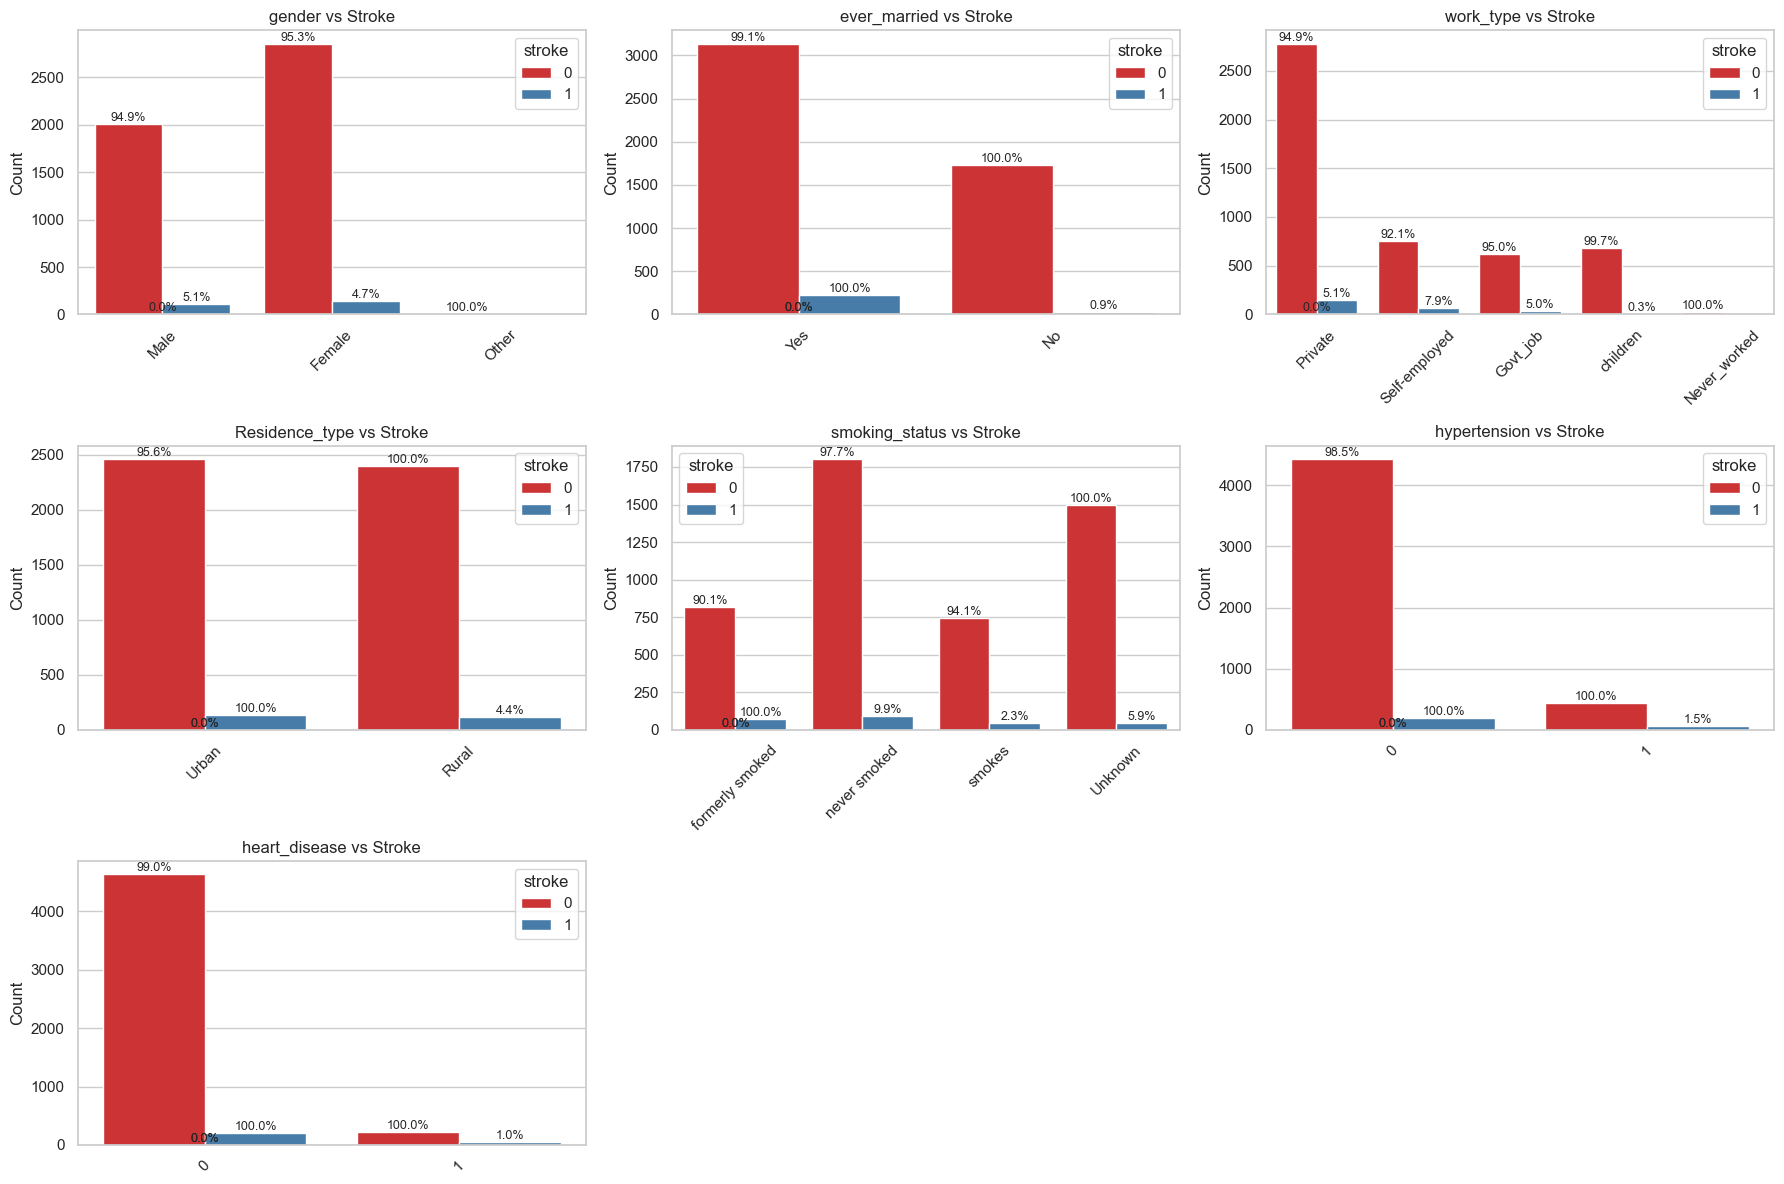

In [10]:
# 1. Categorical vs Target (Stroke)
# We use countplots and the 'hue' parameter to separate the bars by Stroke outcome
plt.figure(figsize=(18, 12))
for i, col in enumerate(categorical_cols):
    ax = plt.subplot(3, 3, i + 1)
    
    # Plotting the countplot with hue='stroke'
    sns.countplot(data=df, x=col, hue=target_col, palette='Set1')
    plt.title(f'{col} vs Stroke', fontsize=12)
    plt.xlabel('')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
        
    # Store heights to calculate bin totals
    patches = ax.patches
    half = len(patches) // 2
    
    for j in range(half):
        # The first half of patches belongs to 'No Stroke' (class 0)
        p1 = patches[j]
        # The second half of patches belongs to 'Stroke' (class 1)
        p2 = patches[j + half]
        
        # Total count for this specific category (e.g. Total Males)
        total_for_category = p1.get_height() + p2.get_height()
        
        if total_for_category > 0:
            p1_pct = f'{100 * p1.get_height() / total_for_category:.1f}%'
            ax.annotate(p1_pct, (p1.get_x() + p1.get_width() / 2, p1.get_height()), ha='center', va='bottom', fontsize=9)
            p2_pct = f'{100 * p2.get_height() / total_for_category:.1f}%'
            ax.annotate(p2_pct, (p2.get_x() + p2.get_width() / 2, p2.get_height()), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

### Count for red and blue bars

In [11]:
for col in categorical_cols:
    print(f"\n==== {col} vs stroke ====")
    
    counts = df.groupby([col, target_col]).size().unstack(fill_value=0)
    counts = counts.rename(columns={0: 'Blue (No Stroke)', 1: 'Red (Stroke)'})
    
    print(counts)


==== gender vs stroke ====
stroke  Blue (No Stroke)  Red (Stroke)
gender                                
Female              2853           141
Male                2007           108
Other                  1             0

==== ever_married vs stroke ====
stroke        Blue (No Stroke)  Red (Stroke)
ever_married                                
No                        1728            29
Yes                       3133           220

==== work_type vs stroke ====
stroke         Blue (No Stroke)  Red (Stroke)
work_type                                    
Govt_job                    624            33
Never_worked                 22             0
Private                    2776           149
Self-employed               754            65
children                    685             2

==== Residence_type vs stroke ====
stroke          Blue (No Stroke)  Red (Stroke)
Residence_type                                
Rural                       2400           114
Urban                       2461 

### Total counts and ratio of all the labels for stroke=1

In [12]:
for col in categorical_cols:
    print(f"\n==== {col} ====")
    
    # Total count per category
    total = df.groupby(col)['stroke'].count()
    
    # Count of stroke = 1 per category
    stroke_count = df.groupby(col)['stroke'].sum()
    
    # Ratio
    ratio = stroke_count / total
    
    # Combine into one table
    result = pd.DataFrame({
        'Total': total,
        'Stroke_Count': stroke_count,
        'Stroke_Ratio': ratio,
        'Stroke%': ratio * 100
    })
    
    print(result)


==== gender ====
        Total  Stroke_Count  Stroke_Ratio   Stroke%
gender                                             
Female   2994           141      0.047094  4.709419
Male     2115           108      0.051064  5.106383
Other       1             0      0.000000  0.000000

==== ever_married ====
              Total  Stroke_Count  Stroke_Ratio   Stroke%
ever_married                                             
No             1757            29      0.016505  1.650541
Yes            3353           220      0.065613  6.561288

==== work_type ====
               Total  Stroke_Count  Stroke_Ratio   Stroke%
work_type                                                 
Govt_job         657            33      0.050228  5.022831
Never_worked      22             0      0.000000  0.000000
Private         2925           149      0.050940  5.094017
Self-employed    819            65      0.079365  7.936508
children         687             2      0.002911  0.291121

==== Residence_type ====
      

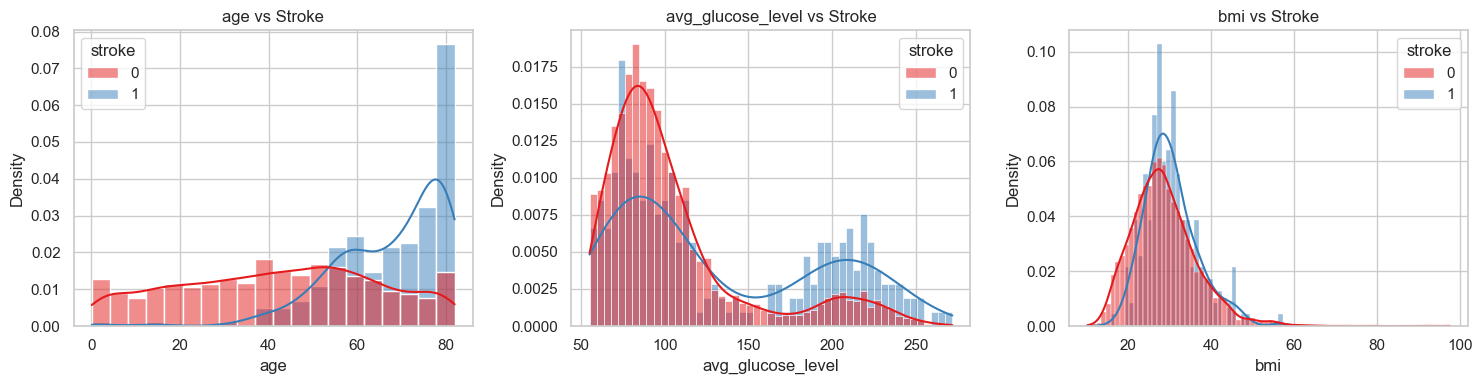

In [13]:

# 2. Numerical vs Target (Histograms with KDE to see overlapping distributions)
plt.figure(figsize=(15, 4))
for i, col in enumerate(numerical_cols):
    plt.subplot(1, 3, i + 1)
    # Using histplot with kde=True gives us both the discrete bins and the smooth density curve.
    # stat='density' and common_norm=False ensures the highly imbalanced classes are scaled to be comparable.
    sns.histplot(data=df, x=col, hue=target_col, kde=True, palette='Set1', stat='density', common_norm=False)
    plt.title(f'{col} vs Stroke', fontsize=12)
    plt.xlabel(col)
plt.tight_layout()
plt.show()

### Correlation Analysis

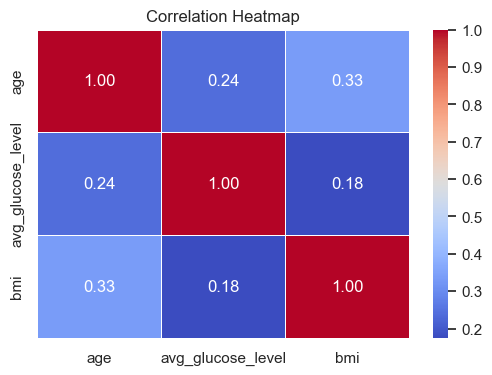

In [14]:
# Correlation Matrix for Numerical Features
plt.figure(figsize=(6, 4))
correlation_matrix = df[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

### Data Preprocessing & Feature Engineering

In [15]:
X = df.drop(['stroke', 'id'], axis=1)
y = df['stroke']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [16]:
# Define custom feature engineering functions
def categorize_features(df_in):
    df = df_in.copy()
    
    # 1. High Glucose Flag
    df['is_high_glucose'] = (df['avg_glucose_level'] > 150).astype(int)
    
    # 2. BMI Categories
    bins = [0, 18.5, 25, 30, 100]
    labels = ['Underweight', 'Normal', 'Overweight', 'Obese']
    # Use fillna to handle missing BMI values temporarily before the imputer catches them
    df['bmi_category'] = pd.cut(df['bmi'].fillna(df['bmi'].median()), bins=bins, labels=labels)
    
    # 3. Age Categories
    age_bins = [0, 18, 65, 150]
    age_labels = ['Child', 'Adult', 'Senior']
    df['age_category'] = pd.cut(df['age'], bins=age_bins, labels=age_labels)
    
    # 4. Health Risk Score (Sum of risk factors)
    df['health_risk_score'] = (
        (df['age_category'] == 'Senior').astype(int) +
        df['hypertension'] +
        df['heart_disease'] +
        (df['bmi_category'].isin(['Overweight', 'Obese'])).astype(int) +
        (df['smoking_status'] == 'smokes').astype(int)
    )
    
    return df

# Create a transformer from our custom function
custom_fe = FunctionTransformer(categorize_features)
custom_fe

,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function cat...002027A202DA0>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional keyword arguments to pass to func... versionadded:: 0.18",None
,"inv_kw_args inv_kw_args: dict, default=NoneDictionary of additional keyword arguments to pass to inverse_func... versionadded:: 0.18",None


In [17]:
# Define which columns get which mathematical treatments
numerical_cols = ['age', 'avg_glucose_level', 'bmi', 'health_risk_score']
# Notice we added our newly engineered categorical features to the categorical list!
categorical_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status', 'bmi_category', 'age_category']

In [18]:
# Numerical Pipeline (Impute missing)
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

# Categorical Pipeline (Impute missing -> OneHotEncode)
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine them into a ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipeline, numerical_cols),
    ('cat', cat_pipeline, categorical_cols)
], remainder='passthrough') # pass through 'is_high_glucose', 'hypertension', etc

# The Master Pipeline!
# (Custom Features -> Clean/Encode -> Model)
full_pipeline = Pipeline([
    ('feature_engineering', custom_fe),
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(eval_metric='logloss', random_state=42))
])

### Model Building

In [19]:
# Train the entire pipeline using the training data
full_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('feature_engineering', ...), ('preprocessor', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function cat...002027A202DA0>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional keyword

In [20]:
# Ask the pipeline to make predictions on the unseen test data
y_pred_base = full_pipeline.predict(X_test)

In [21]:

# Print the classification metrics (Precision, Recall, F1-Score)
print("--- Baseline Classification Report ---")
print(classification_report(y_test, y_pred_base))


--- Baseline Classification Report ---
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       972
           1       0.31      0.08      0.13        50

    accuracy                           0.95      1022
   macro avg       0.63      0.54      0.55      1022
weighted avg       0.92      0.95      0.93      1022



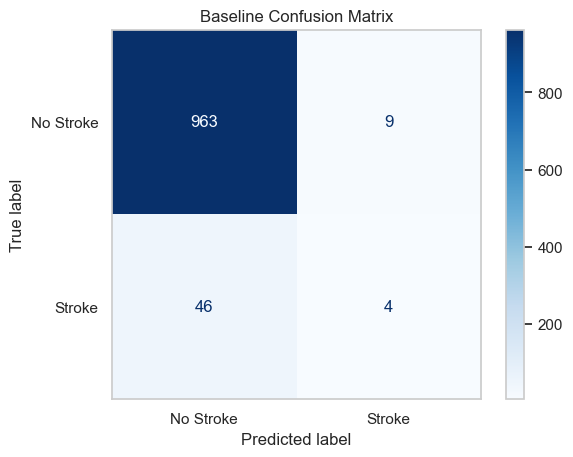

In [67]:
# Generate the confusion matrix to see exactly where the model succeeded and failed
cm = confusion_matrix(y_test, y_pred_base)

# Plot the confusion matrix visually
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Stroke', 'Stroke'])
disp.plot(cmap='Blues')
plt.title('Baseline Confusion Matrix')
plt.grid(False) # Turn off the seaborn grid lines for a cleaner matrix look
plt.show()

### Handling Class Imbalance

In [24]:
# Calculate the exact ratio of negative instances to positive instances
balance_ratio = sum(y_train == 0) / sum(y_train == 1)
print(f"Calculated scale_pos_weight: {balance_ratio:.2f}")

# Re-initialize the pipeline, this time swapping the generic XGBoost for an imbalance-aware one.
tuned_pipeline = Pipeline([
    ('feature_engineering', custom_fe),
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        scale_pos_weight=balance_ratio,
        max_depth=3,                 
        learning_rate=0.01,          
        n_estimators=100,            
        eval_metric='logloss',
        random_state=42
    ))
])

# Train the imbalance-aware model
tuned_pipeline.fit(X_train, y_train)

# Make new predictions
y_pred_tuned = tuned_pipeline.predict(X_test)

Calculated scale_pos_weight: 19.54


In [25]:
# Print the updated metrics
print("--- Tuned Classification Report ---")
print(classification_report(y_test, y_pred_tuned))

--- Tuned Classification Report ---
              precision    recall  f1-score   support

           0       0.99      0.66      0.79       972
           1       0.11      0.84      0.20        50

    accuracy                           0.67      1022
   macro avg       0.55      0.75      0.50      1022
weighted avg       0.94      0.67      0.76      1022



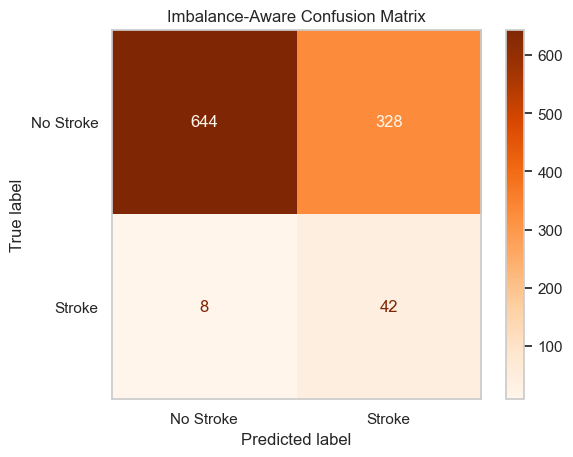

In [26]:
# Generate and plot the new confusion matrix
cm_tuned = confusion_matrix(y_test, y_pred_tuned)
disp_tuned = ConfusionMatrixDisplay(confusion_matrix=cm_tuned, display_labels=['No Stroke', 'Stroke'])
disp_tuned.plot(cmap='Oranges')
plt.title('Imbalance-Aware Confusion Matrix')
plt.grid(False) # Turn off the grid lines
plt.show()

### SMOTE

--- SMOTE Classification Report ---
              precision    recall  f1-score   support

           0       0.98      0.81      0.89       972
           1       0.15      0.66      0.24        50

    accuracy                           0.80      1022
   macro avg       0.56      0.73      0.56      1022
weighted avg       0.94      0.80      0.85      1022



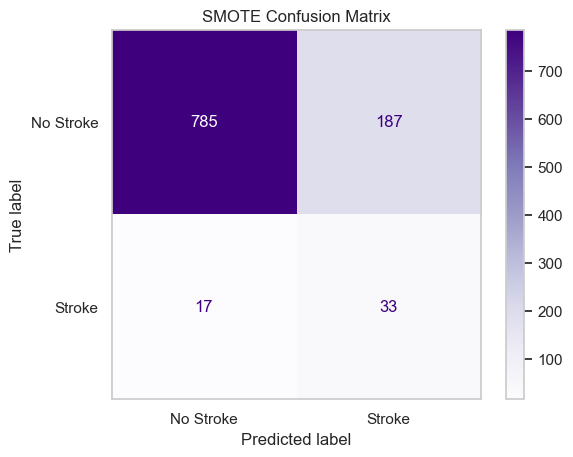

In [27]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

smote_pipeline = ImbPipeline([
    ('feature_engineering', custom_fe),
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', XGBClassifier(
        max_depth=3,                 
        learning_rate=0.01,          
        n_estimators=100,            
        eval_metric='logloss',
        random_state=42
    ))
])

smote_pipeline.fit(X_train, y_train)

# 4. Predict on the untouched, perfectly real Test Data
y_pred_smote = smote_pipeline.predict(X_test)

print("--- SMOTE Classification Report ---")
print(classification_report(y_test, y_pred_smote))

# Plot SMOTE Confusion Matrix
cm_smote = confusion_matrix(y_test, y_pred_smote)
disp_smote = ConfusionMatrixDisplay(confusion_matrix=cm_smote, display_labels=['No Stroke', 'Stroke'])
disp_smote.plot(cmap='Purples')
plt.title('SMOTE Confusion Matrix')
plt.grid(False)
plt.show()

### Hyperparameter Tuning & Threshold Tuning

In [28]:
from sklearn.model_selection import GridSearchCV

# 1. Define the "Grid" of settings we want to test FOR THE CLASSIFIER IN THE PIPELINE
param_grid = {
    'classifier__max_depth': [3, 5],             
    'classifier__learning_rate': [0.01, 0.1],    
    'classifier__n_estimators': [50, 100]        
}

# 2. We use our previously defined weighted pipeline
base_weighted_pipeline = Pipeline([
    ('feature_engineering', custom_fe),
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(scale_pos_weight=balance_ratio, eval_metric='logloss', random_state=42))
])


In [29]:
# Setup GridSearchCV 
# scoring='recall' tells it to explicitly hunt for the model that catches the MOST Strokes!
grid_search = GridSearchCV(
    estimator=base_weighted_pipeline, 
    param_grid=param_grid, 
    cv=3, 
    scoring='recall', 
    verbose=1
)

# Run the Grid Search!
print("Starting Grid Search... this will train 24 completely separate models")
grid_search.fit(X_train, y_train)

Starting Grid Search... this will train 24 completely separate models
Fitting 3 folds for each of 8 candidates, totalling 24 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__learning_rate': [0.01, 0.1], 'classifier__max_depth': [3, 5], 'classifier__n_estimators': [50, 100]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter 

In [30]:
print(f"Best Hyperparameters Found: {grid_search.best_params_}")

Best Hyperparameters Found: {'classifier__learning_rate': 0.01, 'classifier__max_depth': 3, 'classifier__n_estimators': 100}


In [31]:
# Extract the optimized pipeline and test it
best_pipeline = grid_search.best_estimator_

y_pred_best = best_pipeline.predict(X_test)

print("--- Final Optimized (Weighted GridSearch) Classification Report ---")
print(classification_report(y_test, y_pred_best))

--- Final Optimized (Weighted GridSearch) Classification Report ---
              precision    recall  f1-score   support

           0       0.99      0.66      0.79       972
           1       0.11      0.84      0.20        50

    accuracy                           0.67      1022
   macro avg       0.55      0.75      0.50      1022
weighted avg       0.94      0.67      0.76      1022



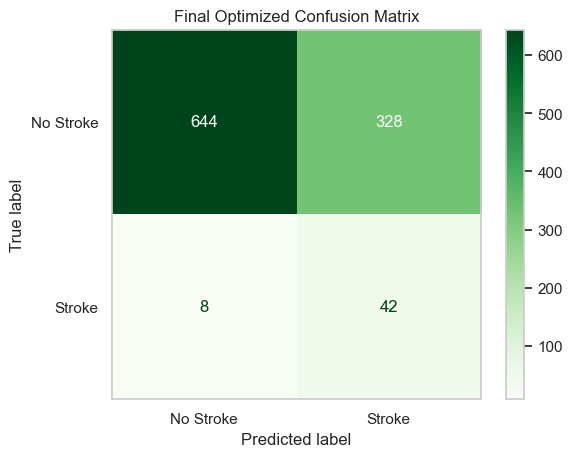

In [80]:
# Final Confusion Matrix
cm_best = confusion_matrix(y_test, y_pred_best)
disp_best = ConfusionMatrixDisplay(confusion_matrix=cm_best, display_labels=['No Stroke', 'Stroke'])
disp_best.plot(cmap='Greens')
plt.title('Final Optimized Confusion Matrix')
plt.grid(False)
plt.show()

In [32]:

import joblib
import os

# Save the entire pipeline object to a .pkl (pickle) file
joblib.dump(best_pipeline, r'C:\Users\ADMIN\Desktop\Logic Mojo_AIML Jan26\AI\Assignment_05\stroke_pipeline_v1.pkl')

print("Model successfully saved to models/stroke_pipeline_v1.pkl!")

Model successfully saved to models/stroke_pipeline_v1.pkl!


## Comparison of XGBoost and Random Forest Models

In [33]:
from sklearn.ensemble import RandomForestClassifier

randomforest_pipeline = Pipeline([
    ('feature_engineering', custom_fe),
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        class_weight="balanced",
        n_estimators=100,
        random_state=42
    ))
])

In [34]:
# Train XGBoost
full_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('feature_engineering', ...), ('preprocessor', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function cat...002027A202DA0>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional keyword

In [35]:
# Train Random Forest
randomforest_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('feature_engineering', ...), ('preprocessor', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function cat...002027A202DA0>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional keyword

In [36]:
y_pred_xgboost = full_pipeline.predict(X_test)
y_pred_rf = randomforest_pipeline.predict(X_test)

In [37]:
from sklearn.metrics import accuracy_score, classification_report

print("=== XGBoost ===")
print("Accuracy:", accuracy_score(y_test, y_pred_xgboost))
print(classification_report(y_test, y_pred_xgboost))

print("\n=== Random Forest ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

=== XGBoost ===
Accuracy: 0.9461839530332681
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       972
           1       0.31      0.08      0.13        50

    accuracy                           0.95      1022
   macro avg       0.63      0.54      0.55      1022
weighted avg       0.92      0.95      0.93      1022


=== Random Forest ===
Accuracy: 0.9481409001956947
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       972
           1       0.00      0.00      0.00        50

    accuracy                           0.95      1022
   macro avg       0.48      0.50      0.49      1022
weighted avg       0.90      0.95      0.93      1022

